# UVA Foreign Giving Analysis

**Goal:** compare UVA to a set of 'peer' institutions and to the national
market overall, then work through a quantitative gap analysis to identify
where UVA may be under-tapping sources of foreign funding that are already
active in higher education.

**A note on peer institutions:** UVA does not publish one single official
peer list; according to UVA "there is no defined
list of peer institutions and the selection of peers may vary, depending on
the comparisons to be made." Here the list will be large public AAU research universities that are routinely used
in UVA benchmarking (Michigan, UNC-Chapel Hill, Berkeley, UCLA,
Wisconsin-Madison, UT Austin, Georgia Tech, Ohio State, Penn State), plus
William & Mary as UVA's closest in-state peer.

**A note on the data:** The Higher Education Act only
requires a gift or contract to be reported once it reaches **\$250,000 from
a single foreign source within a calendar year** (individually or in
combination). Everything below should be read as a comparison of
*large, reportable* foreign donations, not total foreign fundraising.

In [112]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Set the display format for floating point numbers so that readouts are easy to read
pd.options.display.float_format = '{:,.0f}'.format

# Formatting reused across every chart below:
# UVA is always blue
# "peer average" is always orange
# other institutions are neutral gray
#UVA
BLUE = '#2a78d6'
# peer average
ORANGE = '#eb6834'
# other institutions
GRAY = '#c3c2b7'
# black for text and axes
BLK = '#0b0b0b'
# ink for secondary text and labels
INK = '#52514e'
# grid lines
GRID = '#e1e0d9'
# surface background
SURFACE = '#fcfcfb'

# Function to style the axes for consistent appearance across charts and ease of use while plotting
def style_ax(ax):
    ax.set_facecolor(SURFACE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color(GRID)
    ax.tick_params(colors=INK, labelsize=10)
    ax.title.set_color(BLK)


In [113]:
# read in the foreign gifts data
df = pd.read_csv('ForeignGifts_edu.csv')
# this converts the date column to datetime format, and sets origin to 1899-12-30 to avoid issues with weird leap year handling in Excel
df['Date'] = pd.to_datetime(df['Foreign Gift Received Date'],unit='D', origin='1899-12-31')
# this extracts the year from the date column
df['Year'] = df['Date'].dt.year
# print the basic statistics of the data
print(f"{len(df):,} gifts/contracts, {df['Institution Name'].nunique()} institutions, "
      f"years {df['Year'].min()}-{df['Year'].max()}")


28,221 gifts/contracts, 318 institutions, years 2014-2020


In [114]:
# get earliest date in the dataset (confirming the date range above for sanity check)
earliest_date = df['Date'].min()
latest_date = df['Date'].max()

print(f"Earliest date: {earliest_date}")
print(f"Latest date: {latest_date}")

Earliest date: 2014-01-02 00:00:00
Latest date: 2020-07-01 00:00:00


2020 only has 27 records in this dataset (a partial year), so the
year-over-year comparisons below use 2014-2019, the fully covered years.

## Part 1 — UVA's foreign giving profile

In [115]:
# create df of UVA records
uva = df[df['Institution Name'] == 'University of Virginia'].copy()

# calculate total foreign giving and number of gifts for UVA
uva_total = uva['Foreign Gift Amount'].sum()
# calculate the number of foreign gifts/contracts for UVA
uva_count = len(uva)

# calculate total foreign giving and number of gifts for each of all institutions
by_inst_total = df.groupby('Institution Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)
# calculate the number of foreign gifts/contracts for each of all institutions
by_inst_count = df.groupby('Institution Name')['Foreign Gift Amount'].count().sort_values(ascending=False)
# calculate the rank of UVA in total foreign giving and number of gifts among all institutions
rank_total = by_inst_total.index.get_loc('University of Virginia') + 1
# calculate the rank of UVA in number of gifts among all institutions
rank_count = by_inst_count.index.get_loc('University of Virginia') + 1

# print the results
print(f"UVA total foreign giving: ${uva_total:,.0f} across {uva_count} gifts/contracts")
print(f"UVA ranks #{rank_total} of {len(by_inst_total)} institutions by total dollars")
print(f"UVA ranks #{rank_count} of {len(by_inst_count)} institutions by number of gifts")


UVA total foreign giving: $22,189,238 across 98 gifts/contracts
UVA ranks #101 of 318 institutions by total dollars
UVA ranks #57 of 318 institutions by number of gifts


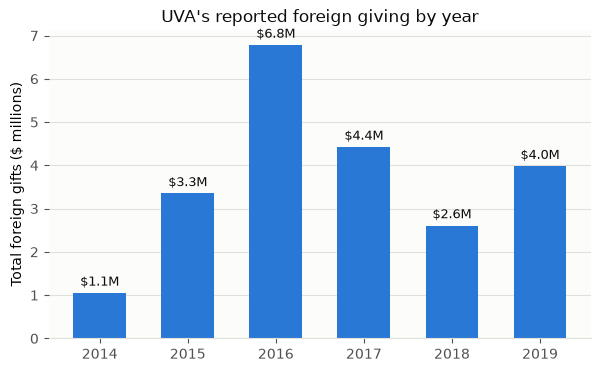

In [116]:
# UVA's total foreign gift dollars, grouped by year
uva_year = uva[uva['Year'] <= 2020].groupby('Year')['Foreign Gift Amount'].sum()

fig, ax = plt.subplots(figsize=(7, 4))

# one bar per year, dollars converted to millions
bars = ax.bar(uva_year.index.astype(str), uva_year.values / 1e6, color=BLUE, width=0.6)

# label each bar with its dollar amount
for bar, dollar_value in zip(bars, uva_year.values):
    x_position = bar.get_x() + bar.get_width() / 2
    y_position = bar.get_height() + 0.1
    label_text = f"${dollar_value / 1e6:,.1f}M"
    ax.text(x_position, y_position, label_text, ha='center', va='bottom', fontsize=9, color=BLK)

ax.set_ylabel('Total foreign gifts ($ millions)')
ax.set_title("UVA's reported foreign giving by year")
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
style_ax(ax)

UVA's reported foreign giving peaked in 2016 and has trended down since; it hasn't grown the way the national market has (see Part 3). There were no contributions to UVA in 2020 (see below for confirmation)

In [117]:
# find latest date for UVA in dataset
latest_date_uva = uva['Date'].max()
print(f"Latest date for UVA: {latest_date_uva}")

Latest date for UVA: 2019-12-20 00:00:00


In [118]:
# calculate the total foreign gifts by gift type for UVA
gift_type = uva.groupby('Gift Type')['Foreign Gift Amount'].agg(total='sum', count='count', mean='mean')
print(gift_type)


                  total  count    mean
Gift Type                             
Contract       14807636     64 231,369
Monetary Gift   7381602     34 217,106


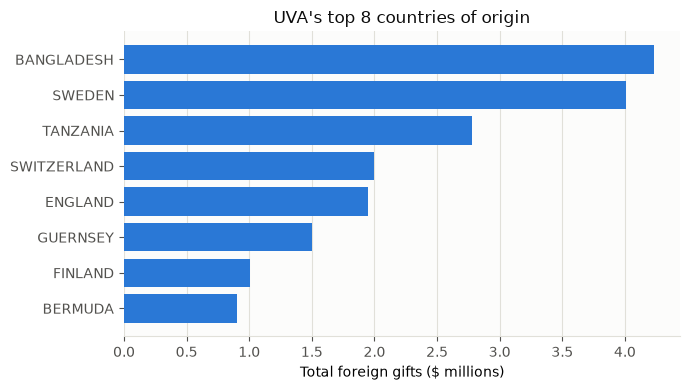

In [119]:
# UVA's total foreign gifts per country, top 8 by dollar amount
uva_country = uva.groupby('Country of Giftor')['Foreign Gift Amount'].sum().sort_values(ascending=False).head(8)

fig, ax = plt.subplots(figsize=(7, 4))
# [::-1] reverses the order so the largest country ends up at the top of the chart
ax.barh(uva_country.index[::-1], uva_country.values[::-1] / 1e6, color=BLUE)
ax.set_xlabel('Total foreign gifts ($ millions)')
ax.set_title("UVA's top 8 countries of origin")
ax.grid(axis='x', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
style_ax(ax)
plt.tight_layout()

In [120]:
# drop rows with no giftor name, then find each giftor's total giving
# 'first' takes one matching country per giftor, since it's the same for all their rows
top_giftors = (uva.dropna(subset=['Giftor Name'])
               .groupby('Giftor Name')
               .agg(total=('Foreign Gift Amount', 'sum'), country=('Country of Giftor', 'first'))
               .sort_values('total', ascending=False).head(10))
print(top_giftors)

                                       total      country
Giftor Name                                              
AstraZeneca                          3208048       SWEDEN
Intrnl Centre Diarrheal Disease      1382896   BANGLADESH
Haydom Lutheran Hospital d/b/a Hayd  1100553     TANZANIA
Haydom Luther Hospital               1035339     TANZANIA
Harvest Group Holding                1000000     GUERNSEY
Lawrence D/ Karin S Howell           1000000  SWITZERLAND
Lawrence D & Karin S Howell          1000000  SWITZERLAND
Danisco Sweeteners Oy                 990331      FINLAND
Intnl Centre for Diarrhoeal Disease   919857   BANGLADESH
International Centre for Diarrhoeal   919518   BANGLADESH


UVA's largest individual foreign relationships are concentrated in research/medical partnerships — AstraZeneca, Haydom Lutheran Hospital (Tanzania), and the International Centre for Diarrhoeal Disease Research (Bangladesh) among them. That supports the country list above: Bangladesh and Tanzania rank among UVA's top sources specifically b/c of one or two large sponsored-research relationships.

## Part 2 — UVA vs. peer institutions

Peer group used below (see the note in the introduction for the
rationale):

In [121]:
# the peer group used throughout this notebook (see the intro for why these schools)
PEERS = [
    'University of Virginia',
    'University of Michigan - Ann Arbor',
    'University of North Carolina - Chapel Hill',
    'University of California, Berkeley',
    'University of California, Los Angeles',
    'University of Wisconsin - Madison',
    'University of Texas at Austin',
    'Georgia Institute of Technology',
    'Ohio State University (The)',
    'Pennsylvania State University (The)',
    'College of William & Mary',
]
PEER_OTHERS = [p for p in PEERS if p != 'University of Virginia']  # for comparing UVA against the rest

peer_df = df[df['Institution Name'].isin(PEERS)]

# total $, number of gifts, and average gift size, per institution
peer_summary = peer_df.groupby('Institution Name').agg(
    total=('Foreign Gift Amount', 'sum'),
    count=('Foreign Gift Amount', 'count'),
    mean=('Foreign Gift Amount', 'mean'),
).sort_values('total', ascending=False)
print(peer_summary)

                                                total  count    mean
Institution Name                                                    
University of California, Berkeley          294479904    394 747,411
University of Michigan - Ann Arbor          287336783    715 401,870
University of California, Los Angeles       242146363   3916  61,835
University of Texas at Austin                85858408    377 227,741
Georgia Institute of Technology              77979361    203 384,135
Ohio State University (The)                  58277670   1014  57,473
Pennsylvania State University (The)          43458897    174 249,764
University of North Carolina - Chapel Hill   41292544    286 144,380
University of Wisconsin - Madison            22945761     38 603,836
University of Virginia                       22189238     98 226,421
College of William & Mary                     3384498     17 199,088


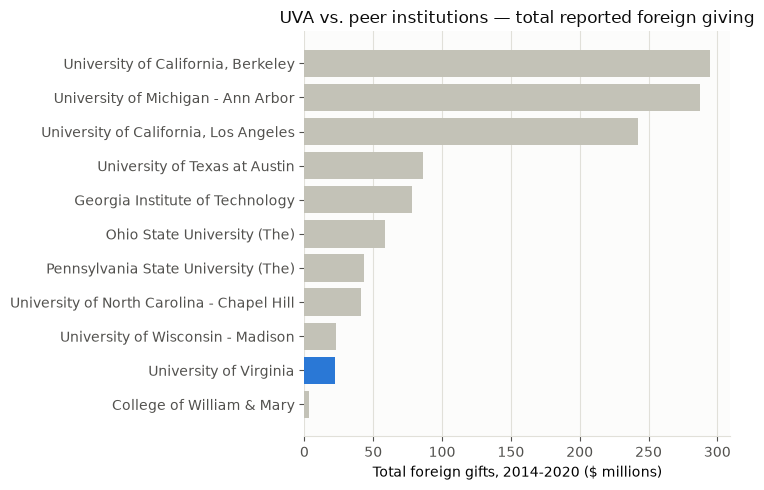

In [122]:
fig, ax = plt.subplots(figsize=(7.5, 5))

# sort ascending so the largest institution ends up at the top of the chart
order = peer_summary.sort_values('total').index

# color UVA's bar differently so it stands out from the rest of the peer group; institutions are shown in order of total foreign gifts
colors = [BLUE if inst == 'University of Virginia' else GRAY for inst in order]

ax.barh(order, peer_summary.loc[order, 'total'] / 1e6, color=colors)
ax.set_xlabel('Total foreign gifts, 2014-2020 ($ millions)')
ax.set_title('UVA vs. peer institutions — total reported foreign giving')
ax.grid(axis='x', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
style_ax(ax)
plt.tight_layout()


Among these 11 institutions, UVA ranks 10th of 11 by total dollars, ahead of only William & Mary. UVA is well behind Berkeley, Michigan, and UCLA, each of which reports well over \$200M. UVA isn't absent from foreign giving, tallying 98 reportable gifts (57th nationally by count); however, the contribution size ($) of UVA's relationships is small relative to this peer set.

## Part 3 — UVA vs. the national market

In [123]:
# total dollars and gift count across every institution, for comparison against UVA
national_total = df['Foreign Gift Amount'].sum()
national_count = len(df)
print(f"National total (all {df['Institution Name'].nunique()} institutions): ${national_total:,.0f} "
      f"across {national_count:,} gifts/contracts")
print(f"UVA's share: {uva_total/national_total*100:.3f}% of dollars, "
      f"{uva_count/national_count*100:.3f}% of gift count")

National total (all 318 institutions): $16,600,515,514 across 28,221 gifts/contracts
UVA's share: 0.134% of dollars, 0.347% of gift count


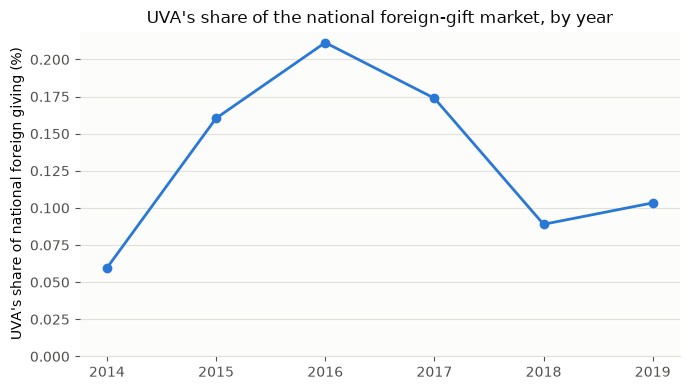

In [124]:
# national total by year, same shape as uva_year, so the two can be compared directly
nat_year = df[df['Year'] <= 2019].groupby('Year')['Foreign Gift Amount'].sum()
# UVA's total as a percentage of the national total, year by year
uva_share = (uva_year / nat_year * 100)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(uva_share.index.astype(str), uva_share.values, color=BLUE, marker='o',
        markersize=6, linewidth=2)
ax.set_ylabel("UVA's share of national foreign giving (%)")
ax.set_title("UVA's share of the national foreign-gift market, by year")
ax.grid(axis='y', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.set_ylim(bottom=0)
style_ax(ax)
plt.tight_layout()

The national market for reportable foreign gifts roughly doubled from 2014 to 2019 (\$1.9B to \$4.0B). UVA's dollar share of that market has stayed under a quarter of one percent throughout, and even trended down from 2016 to 2018.

## Part 4 — Where's the opportunity?

For each country, this compares what UVA received to what the other ten peer institutions received on average from that same country. A large gap indicates peers are receiving substantial gifts from a country that has given little or nothing to UVA. These could represent opportunities to build relationships & access funding. 

In [ ]:
# pivot into a table: one row per institution, one column per country
by_country = peer_df.groupby(['Institution Name', 'Country of Giftor'])['Foreign Gift Amount'].sum().unstack(fill_value=0)

uva_by_country = by_country.loc['University of Virginia']

# average across the other 10 peers, per country
peer_avg_by_country = by_country.loc[PEER_OTHERS].mean()  

# how much more (or less) the average peer got from each country than UVA did
gap = pd.DataFrame({'uva': uva_by_country, 'peer_avg': peer_avg_by_country}).fillna(0)
gap['gap'] = gap['peer_avg'] - gap['uva']
top_gap = gap.sort_values('gap', ascending=False).head(8)
print(top_gap)

                       uva   peer_avg        gap
Country of Giftor                               
ENGLAND            1950666 16,910,121 14,959,455
JAPAN               265970 12,019,027 11,753,057
CHINA                    0 11,643,568 11,643,568
SAUDI ARABIA             0  7,441,856  7,441,856
GERMANY                  0  7,055,565  7,055,565
CANADA                   0  6,052,035  6,052,035
HONG KONG                0  5,287,924  5,287,924
SWITZERLAND        2000000  7,029,362  5,029,362


*Worth pointing out that we're treating Hong Kong as a country in this lab: its not. It does, however, make donations to institutions as its own 'administrative province,' so for the sake of the study, it's represented alongside other countries.*

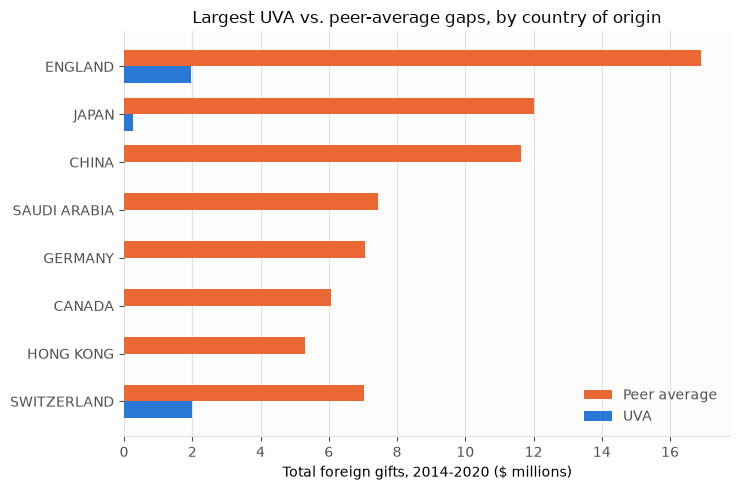

In [ ]:
fig, ax = plt.subplots(figsize=(7.5, 5))

h = 0.35  # bar height — used to offset the two bars per country so they sit side by side
order = top_gap.index[::-1]  # reversed so the largest gap ends up at the top of the chart

# two bars per country: peer average shifted up, UVA shifted down, so they don't overlap
ax.barh(np.arange(len(order)) + h/2, top_gap.loc[order, 'peer_avg'] / 1e6, height=h,
        color=ORANGE, label='Peer average')
ax.barh(np.arange(len(order)) - h/2, top_gap.loc[order, 'uva'] / 1e6, height=h,
        color=BLUE, label='UVA')

# manually attach the country names as the tick labels since the bars are plotted at numeric positions
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels(order)

ax.set_xlabel('Total foreign gifts, 2014-2020 ($ millions)')
ax.set_title('Largest UVA vs. peer-average gaps, by country of origin')
ax.legend(frameon=False, labelcolor=INK)
ax.grid(axis='x', color=GRID, linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
style_ax(ax)
plt.tight_layout()


In [127]:
print("Which peer institution is currently capturing each gap country's money:")
for country in top_gap.index:
    top_recipient = by_country[country].loc[PEER_OTHERS].sort_values(ascending=False)
    print(f"  {country:<15} -> {top_recipient.index[0]:<38} ${top_recipient.iloc[0]:>14,.0f}")


Which peer institution is currently capturing each gap country's money:
  ENGLAND         -> University of California, Los Angeles  $    53,959,295
  JAPAN           -> University of California, Los Angeles  $    52,335,423
  CHINA           -> University of California, Berkeley     $    35,876,428
  SAUDI ARABIA    -> University of California, Berkeley     $    21,348,560
  GERMANY         -> University of California, Berkeley     $    28,890,715
  CANADA          -> University of North Carolina - Chapel Hill $    14,042,140
  HONG KONG       -> University of California, Berkeley     $    19,057,414
  SWITZERLAND     -> University of Michigan - Ann Arbor     $    25,013,810


Five of these eight donors (China, Saudi Arabia, Germany, Canada, and Hong Kong (considered country in for this lab)) show $0 in reportable gifts to UVA over this entire period, despite each having given donations to at least one of UVA's peers (Berkeley especially). England and Japan aren't at zero for UVA, but the gap is still very large compared to the institutional peer average. This could be an opportunity for UVA to collect more donations from countries that clearly have interest in supporting similar institutions, and a budget to back. 